# Decision Tree Lab

In [ ]:
from sklearn.tree import DecisionTreeClassifier
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import arff
from sklearn.model_selection import train_test_split

## 1 Debug and Eval

### 1.1 Debug

- Train a DecisionTreeClassifier on the [Iris Dataset](https://raw.githubusercontent.com/cs472ta/CS472/master/datasets/iris.arff) using all default parameters.
- If using Dataframes you may want to change the class values from bytecodes to strings with
iris_df['class'] = iris_df['class'].str.decode('utf-8')

Expected Accuracy = [1.0]


In [ ]:
#Debug
!pip install ucimlrepo
from ucimlrepo import fetch_ucirepo

# fetch dataset
iris = fetch_ucirepo(id=53)

# data (as pandas dataframes)
X = iris.data.features
y = iris.data.targets

# metadata
print(iris.metadata)

# variable information
print(iris.variables)

{'uci_id': 53, 'name': 'Iris', 'repository_url': 'https://archive.ics.uci.edu/dataset/53/iris', 'data_url': 'https://archive.ics.uci.edu/static/public/53/data.csv', 'abstract': 'A small classic dataset from Fisher, 1936. One of the earliest known datasets used for evaluating classification methods.\n', 'area': 'Biology', 'tasks': ['Classification'], 'characteristics': ['Tabular'], 'num_instances': 150, 'num_features': 4, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1936, 'last_updated': 'Tue Sep 12 2023', 'dataset_doi': '10.24432/C56C76', 'creators': ['R. A. Fisher'], 'intro_paper': {'ID': 191, 'type': 'NATIVE', 'title': 'The Iris data set: In search of the source of virginica', 'authors': 'A. Unwin, K. Kleinman', 'venue': 'Significance, 2021', 'year': 2021, 'journal': 'Significance, 2021', 'DOI': '1740-9713.01589', 'URL': 'https://www.semanticscholar.org

In [ ]:
tree = DecisionTreeClassifier()
tree.fit(X, y)
tree.score(X,y)

1.0

### 1.2 Evaluation

- Train on the iris data set again but this time with max_depth = 3 and output the accuracy

In [ ]:
# Evaluation
tree = DecisionTreeClassifier(max_depth=3)
tree.fit(X, y)
tree.score(X,y)

0.9733333333333334

#### Discussion
What did you see? What were the differences in accuracy between the two trained models? How do you account for the differences or no differences?

The accuracy score for a decision tree classifier with the default parameters ends up at 100%. When we change the max depth to 3, the accuracy score comes down slightly to 97.3%. I would thus infer that the limit on depth limits the accuracy of the decision tree model with this dataset.

## 2. Missing Values, N-fold CV, and Decision Tree Items  

### 2.1 Handling missing values
- Use this [Voting Dataset with missing values](https://raw.githubusercontent.com/cs472ta/CS472/master/datasets/voting_with_missing.arff)
- This data set has missing data.  Create an extra feature value for each feature with missing data. For example, if the feature were color with possible values R, G, B, you would add a fourth value (e.g. U or ? for unknown).
- Do not use a stopping criteria. Induce the tree as far as it can go (until classes are pure or there are no more data or attributes to split on).
- SKlearn does not allow nominal features, which initially seems odd. However, SKlearn uses the binary CART algorithm where a nominal data value like color is broken down into blue or not blue, red or not red, etc.  It is thus natural to just use one-hot encoding for each nominal feature.
- Use an 80/20 train/test split.
- Report the training and test set accuracies.

In [ ]:
# Learn Voting with missing values.
!wget https://raw.githubusercontent.com/cs472ta/CS472/master/datasets/voting_with_missing.arff
from scipy.io import arff
data, metadata = arff.loadarff('voting_with_missing.arff')
df_voter = pd.DataFrame(data)
df_voter.head()

--2025-10-29 04:17:19--  https://raw.githubusercontent.com/cs472ta/CS472/master/datasets/voting_with_missing.arff
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 40261 (39K) [text/plain]
Saving to: ‘voting_with_missing.arff.6’

voting_with_missing 100%[===================>]  39.32K  --.-KB/s    in 0.004s  

2025-10-29 04:17:19 (8.83 MB/s) - ‘voting_with_missing.arff.6’ saved [40261/40261]



,handicapped-infants,water-project-cost-sharing,adoption-of-the-budget-resolution,physician-fee-freeze,el-salvador-aid,religious-groups-in-schools,anti-satellite-test-ban,aid-to-nicaraguan-contras,mx-missile,immigration,synfuels-corporation-cutback,education-spending,superfund-right-to-sue,crime,duty-free-exports,export-administration-act-south-africa,Class
0,b'n',b'y',b'n',b'y',b'y',b'y',b'n',b'n',b'n',b'y',b'?',b'y',b'y',b'y',b'n',b'y',b'republican'
1,b'n',b'y',b'n',b'y',b'y',b'y',b'n',b'n',b'n',b'n',b'n',b'y',b'y',b'y',b'n',b'?',b'republican'
2,b'?',b'y',b'y',b'?',b'y',b'y',b'n',b'n',b'n',b'n',b'y',b'n',b'y',b'y',b'n',b'n',b'democrat'
3,b'n',b'y',b'y',b'n',b'?',b'y',b'n',b'n',b'n',b'n',b'y',b'n',b'y',b'n',b'n',b'y',b'democrat'
4,b'y',b'y',b'y',b'n',b'y',b'y',b'n',b'n',b'n',b'n',b'y',b'?',b'y',b'y',b'y',b'y',b'democrat'


In [ ]:
for i in df_voter.columns:
  print(df_voter[i].value_counts())

handicapped-infants
b'n'    236
b'y'    187
b'?'     12
Name: count, dtype: int64
water-project-cost-sharing
b'y'    195
b'n'    192
b'?'     48
Name: count, dtype: int64
adoption-of-the-budget-resolution
b'y'    253
b'n'    171
b'?'     11
Name: count, dtype: int64
physician-fee-freeze
b'n'    247
b'y'    177
b'?'     11
Name: count, dtype: int64
el-salvador-aid
b'y'    212
b'n'    208
b'?'     15
Name: count, dtype: int64
religious-groups-in-schools
b'y'    272
b'n'    152
b'?'     11
Name: count, dtype: int64
anti-satellite-test-ban
b'y'    239
b'n'    182
b'?'     14
Name: count, dtype: int64
aid-to-nicaraguan-contras
b'y'    242
b'n'    178
b'?'     15
Name: count, dtype: int64
mx-missile
b'y'    207
b'n'    206
b'?'     22
Name: count, dtype: int64
immigration
b'y'    216
b'n'    212
b'?'      7
Name: count, dtype: int64
synfuels-corporation-cutback
b'n'    264
b'y'    150
b'?'     21
Name: count, dtype: int64
education-spending
b'n'    233
b'y'    171
b'?'     31
Name: count, dt

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for i in df_voter.columns:
  df_voter[i] = le.fit_transform(df_voter[i])
df_voter.head()

,handicapped-infants,water-project-cost-sharing,adoption-of-the-budget-resolution,physician-fee-freeze,el-salvador-aid,religious-groups-in-schools,anti-satellite-test-ban,aid-to-nicaraguan-contras,mx-missile,immigration,synfuels-corporation-cutback,education-spending,superfund-right-to-sue,crime,duty-free-exports,export-administration-act-south-africa,Class
0,1,2,1,2,2,2,1,1,1,2,0,2,2,2,1,2,1
1,1,2,1,2,2,2,1,1,1,1,1,2,2,2,1,0,1
2,0,2,2,0,2,2,1,1,1,1,2,1,2,2,1,1,0
3,1,2,2,1,0,2,1,1,1,1,2,1,2,1,1,2,0
4,2,2,2,1,2,2,1,1,1,1,2,0,2,2,2,2,0


In [ ]:
tree = DecisionTreeClassifier()
X_voter = df_voter.drop('Class', axis=1)
y_voter = df_voter['Class']
X_train, X_test, y_train, y_test = train_test_split(X_voter, y_voter, test_size=0.2, random_state=42)
tree.fit(X_train, y_train)
print(f"training accuracy: {tree.score(X_train, y_train)}")
print(f"test accuracy: {tree.score(X_test, y_test)}")

training accuracy: 1.0
test accuracy: 0.9195402298850575


#### Discussion
Report on your accuracies and include explaining how the missing values were handled by your model

The decision tree classifier with no stopping criteria and default parameters for the remaining options had an accuracy of 100% with the training set and about 93% accuracy with the test set. The missing values were simply encoded as a different observation in training the model.

### 2.2 N-fold Cross Validation
- Learn the [Cars Dataset](https://raw.githubusercontent.com/cs472ta/CS472/master/datasets/cars.arff) with the decision tree.
- Create a table with the 10-fold cross validation accuracies and show the average predicted accuracy.
- Try it again with 5-fold CV and create and show that table also.

In [ ]:
from sklearn.model_selection import cross_val_score

In [ ]:
!wget https://raw.githubusercontent.com/cs472ta/CS472/master/datasets/cars.arff
data, metadata = arff.loadarff('cars.arff')
df_cars = pd.DataFrame(data)
df_cars.head()

--2025-10-29 04:17:19--  https://raw.githubusercontent.com/cs472ta/CS472/master/datasets/cars.arff
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 55386 (54K) [text/plain]
Saving to: ‘cars.arff.7’

cars.arff.7         100%[===================>]  54.09K  --.-KB/s    in 0.01s   

2025-10-29 04:17:19 (4.37 MB/s) - ‘cars.arff.7’ saved [55386/55386]



,buying,maint,doors,persons,lug_boot,safety,class
0,b'vhigh',b'vhigh',b'2',b'2',b'small',b'low',b'unacc'
1,b'vhigh',b'vhigh',b'2',b'2',b'small',b'med',b'unacc'
2,b'vhigh',b'vhigh',b'2',b'2',b'small',b'high',b'unacc'
3,b'vhigh',b'vhigh',b'2',b'2',b'med',b'low',b'unacc'
4,b'vhigh',b'vhigh',b'2',b'2',b'med',b'med',b'unacc'


In [ ]:
for i in df_cars.columns:
  print(df_cars[i].value_counts())

buying
b'vhigh'    432
b'high'     432
b'med'      432
b'low'      432
Name: count, dtype: int64
maint
b'vhigh'    432
b'high'     432
b'med'      432
b'low'      432
Name: count, dtype: int64
doors
b'2'        432
b'3'        432
b'4'        432
b'5more'    432
Name: count, dtype: int64
persons
b'2'       576
b'4'       576
b'more'    576
Name: count, dtype: int64
lug_boot
b'small'    576
b'med'      576
b'big'      576
Name: count, dtype: int64
safety
b'low'     576
b'med'     576
b'high'    576
Name: count, dtype: int64
class
b'unacc'    1210
b'acc'       384
b'good'       69
b'vgood'      65
Name: count, dtype: int64


In [ ]:
print(df_cars.columns)
for i in df_cars.columns:
  df_cars[i] = le.fit_transform(df_cars[i])
df_cars.head()

Index(['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class'], dtype='object')


,buying,maint,doors,persons,lug_boot,safety,class
0,3,3,0,0,2,1,2
1,3,3,0,0,2,2,2
2,3,3,0,0,2,0,2
3,3,3,0,0,1,1,2
4,3,3,0,0,1,2,2


In [ ]:
X_cars = df_cars.drop('class', axis=1)
y_cars = df_cars['class']
tree = DecisionTreeClassifier()
ten_cv_scores = cross_val_score(tree, X_cars, y_cars, cv=10)
print(f"10-fold CV scores: {ten_cv_scores}")
five_cv_scores = cross_val_score(tree, X, y, cv=5)
print(f"5-fold CV scores: {five_cv_scores}")

10-fold CV scores: [0.62427746 0.79190751 0.93063584 0.78034682 0.9017341  0.94797688
 0.87283237 0.89017341 0.95930233 0.95348837]
5-fold CV scores: [0.96666667 0.96666667 0.9        1.         1.        ]


In [ ]:
print(f"mean 10 CV score: {ten_cv_scores.mean()}")
print(f"mean  5 CV score: {five_cv_scores.mean()}")

mean 10 CV score: 0.8652675090738002
mean  5 CV score: 0.9666666666666668


#### Discussion
Explain n-fold cross validation. Why do we do it? How is it useful? What does it reveal? Do we end up with a model? If so, which one?

N-fold cross validation is where the dataset is split into $n$ number of folds and a particular fold is used as a validation set while the remaining $n-1$ folds are used as the training set. We iterate through each combination of validation and training folds to get a better idea of the accuracy of the model.

### 2.3 Decision Tree Intuition
For each of the two problems above (Voting and Cars):
- Print the full tree for each.  You may use tree.plot_tree(clf) or [another way](https://mljar.com/blog/visualize-decision-tree/) if you prefer.  tree.plot_tree has a number of parameters which you can try which let you print more informative trees which can help your discussion.
- Train both again with max_depth = 2 and print these smaller trees and include them in your report.
- Summarize in English what these 2 smaller decision trees have learned (i.e. look at the induced trees and describe what "rules" they discovered).
- Compare your thoughts on important features with the attribute feature_importances_

In [ ]:
#Print induced trees for the voting and car data sets
from sklearn import tree
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

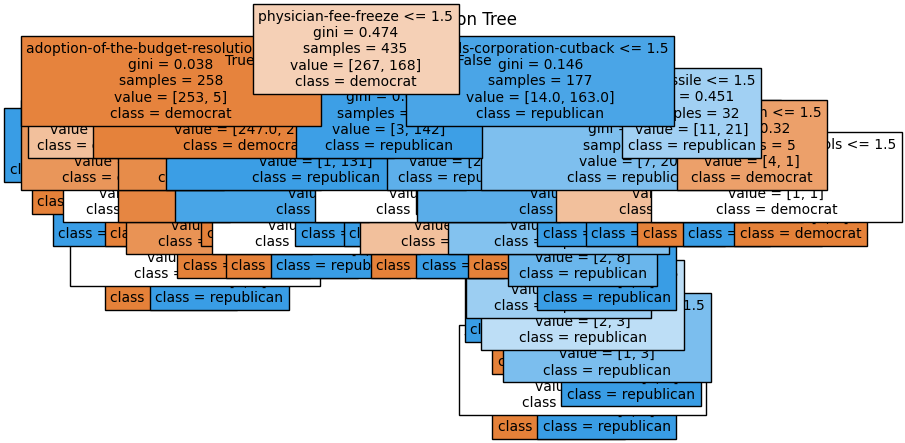

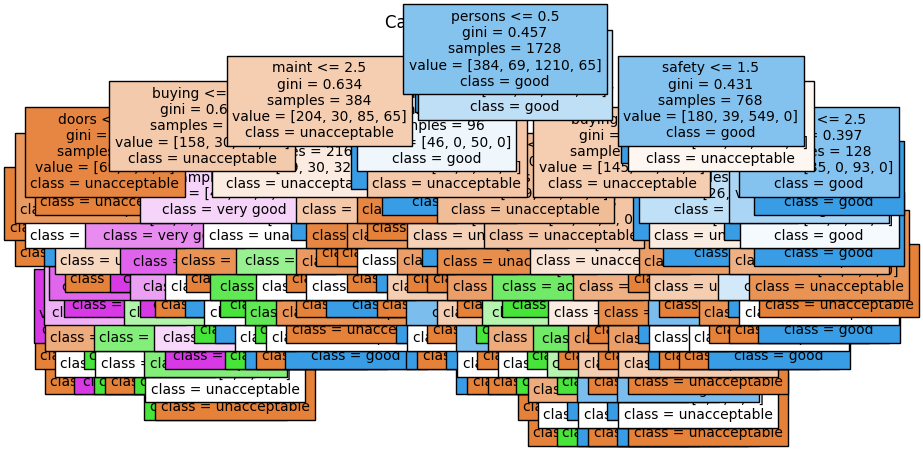

In [ ]:
tree = DecisionTreeClassifier()
tree.fit(X_voter, y_voter)
plt.figure(figsize=(10, 5))
plot_tree(tree,
          feature_names=df_voter.columns,
          class_names=['democrat', 'republican'],
          filled=True,
          fontsize=10)
plt.title("Voter Decision Tree")
plt.show()
tree.fit(X_cars, y_cars)
plt.figure(figsize=(10, 5))
plot_tree(tree,
          feature_names=df_cars.columns,
          class_names=['unacceptable', 'acceptable', 'good', 'very good'],
          filled=True,
          fontsize=10)
plt.title("Cars Decision Tree")
plt.show()

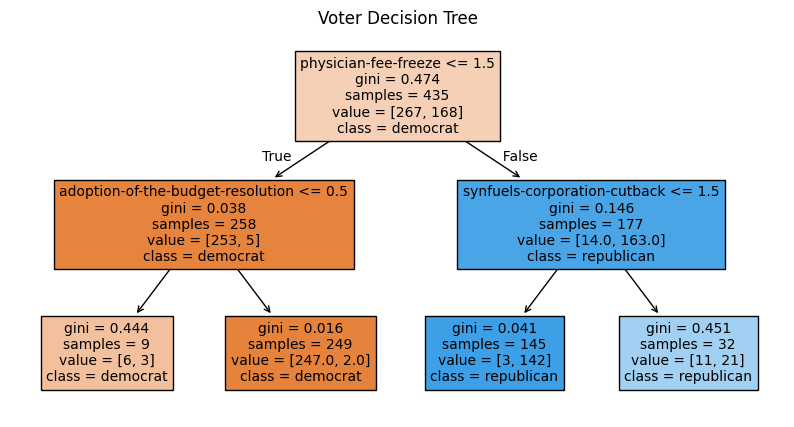

Feature Importances:
handicapped-infants: 0.0
water-project-cost-sharing: 0.0
adoption-of-the-budget-resolution: 0.010330410221054185
physician-fee-freeze: 0.958920228977819
el-salvador-aid: 0.0
religious-groups-in-schools: 0.0
anti-satellite-test-ban: 0.0
aid-to-nicaraguan-contras: 0.0
mx-missile: 0.0
immigration: 0.0
synfuels-corporation-cutback: 0.03074936080112677
education-spending: 0.0
superfund-right-to-sue: 0.0
crime: 0.0
duty-free-exports: 0.0
export-administration-act-south-africa: 0.0


In [ ]:
tree = DecisionTreeClassifier(max_depth=2)
tree.fit(X_voter, y_voter)
plt.figure(figsize=(10, 5))
plot_tree(tree,
          feature_names=df_voter.columns,
          class_names=['democrat', 'republican'],
          filled=True,
          fontsize=10)
plt.title("Voter Decision Tree")
plt.show()
feature_importances = tree.feature_importances_
print("Feature Importances:")
for i in range(len(feature_importances)):
  print(f"{df_voter.columns[i]}: {feature_importances[i]}")

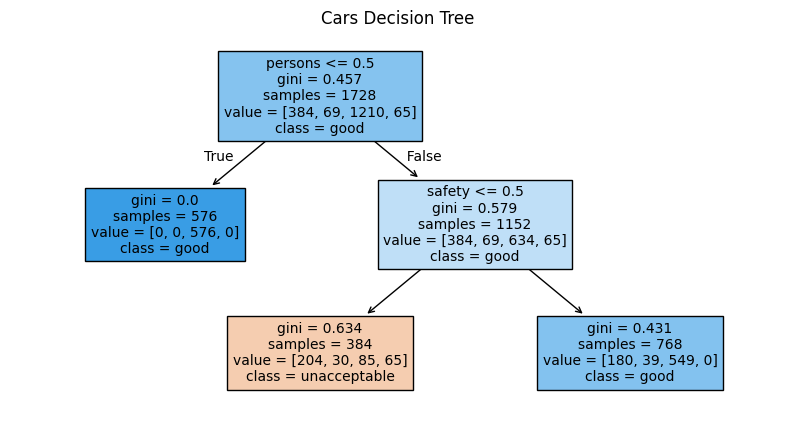

Feature Importances:
buying: 0.0
maint: 0.0
doors: 0.0
persons: 0.5707571064813255
lug_boot: 0.0
safety: 0.42924289351867445


In [ ]:
tree.fit(X_cars, y_cars)
plt.figure(figsize=(10, 5))
plot_tree(tree,
          feature_names=df_cars.columns,
          class_names=['unacceptable', 'acceptable', 'good', 'very good'],
          filled=True,
          fontsize=10)
plt.title("Cars Decision Tree")
plt.show()
feature_importances = tree.feature_importances_
print("Feature Importances:")
for i in range(len(feature_importances)):
  print(f"{df_cars.columns[i]}: {feature_importances[i]}")

#### Discussion
Discuss what the Trees have learned on the 2 data sets (i.e. look at the induced trees and describe what "rules" they discovered). How do the important features you would think about correspond the the "feature_importances_"

Looking at the max_depth=2 decision tree for the voter dataset, it seems like the classifier has determined that it will first decide based on the physician fee freeze parameter. If that decision is made true, then it classifies those people (including with following decisions) as democrat, and republican if the opposite is true.
The feature importances also indicates that the physician-fee-freeze is by far the most important feature in making decisions, with two other negligable ones.

Looking at the decision tree for the cars dataset, it first makes a decision based on the persons parameter. If the car can hold more than two people and the savety is low, then the car is classified as unnacceptable, and good otherwise.
The feature importances indicate that persons and safety are the two important features in making decisions, each of them about equally important.

### 2.4 Other Parameters
- For either of the data sets above experiment and discuss using a different split criterion (Compare Entropy and Log-loss with Gini)

In [ ]:
# Experiment with criterion parameter
tree_entropy = DecisionTreeClassifier(criterion='entropy')
X_train, X_test, y_train, y_test = train_test_split(X_voter, y_voter, test_size=0.2, random_state=42)
tree_entropy.fit(X_train, y_train)
print(f"training accuracy: {tree_entropy.score(X_train, y_train)}")
print(f"test accuracy: {tree_entropy.score(X_test, y_test)}")
print("\n")
print("Feature Importances:")
for i in range(len(feature_importances)):
  print(f"{df_voter.columns[i]}: {feature_importances[i]}")

training accuracy: 1.0
test accuracy: 0.9425287356321839


Feature Importances:
handicapped-infants: 0.0
water-project-cost-sharing: 0.0
adoption-of-the-budget-resolution: 0.0
physician-fee-freeze: 0.5707571064813255
el-salvador-aid: 0.0
religious-groups-in-schools: 0.42924289351867445


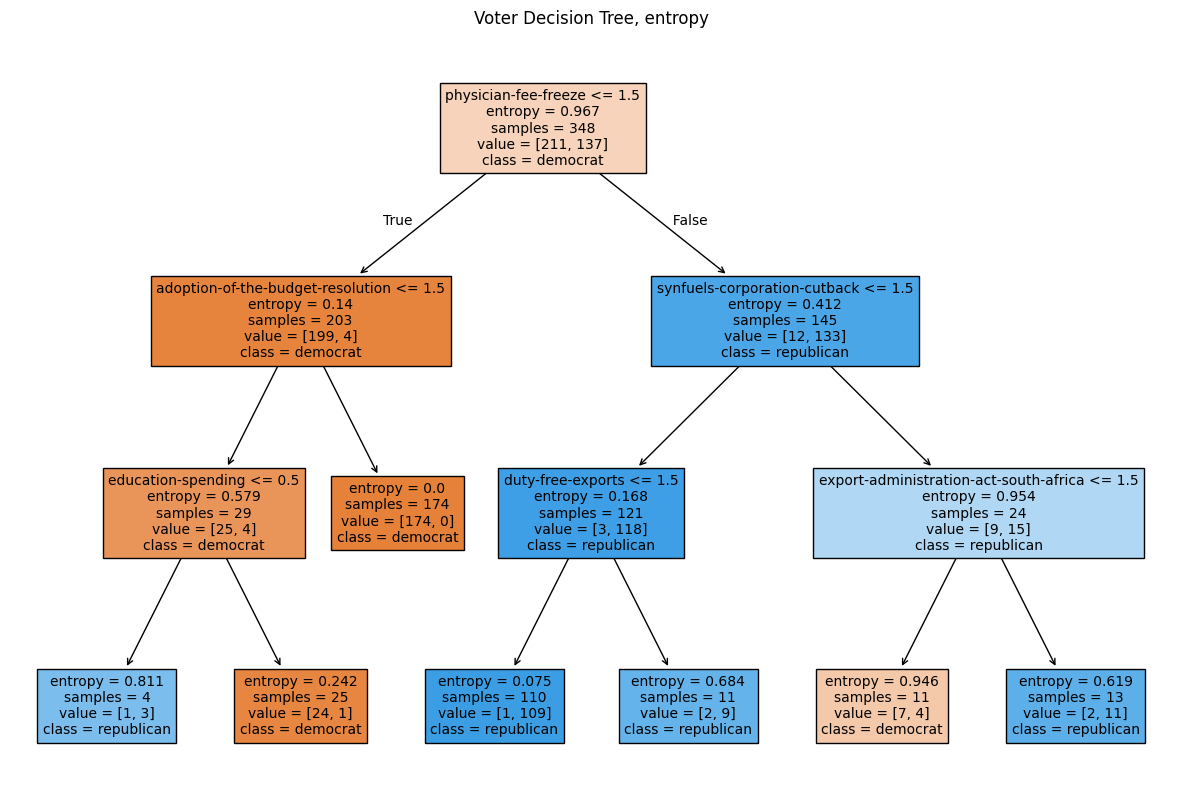

In [ ]:
tree_entropy =  DecisionTreeClassifier(criterion='entropy', max_depth=3)
tree_entropy.fit(X_train, y_train)
plt.figure(figsize=(15, 10))
plot_tree(tree_entropy,
          feature_names=df_voter.columns,
          class_names=['democrat', 'republican'],
          filled=True,
          fontsize=10)
plt.title("Voter Decision Tree, entropy")
plt.show()

In [ ]:
tree_logloss = DecisionTreeClassifier(criterion='log_loss')
tree_logloss.fit(X_train, y_train)
print(f"training accuracy: {tree_logloss.score(X_train, y_train)}")
print(f"test accuracy: {tree_logloss.score(X_test, y_test)}")
print("\n")
print("Feature Importances:")
for i in range(len(feature_importances)):
  print(f"{df_voter.columns[i]}: {feature_importances[i]}")

training accuracy: 1.0
test accuracy: 0.9195402298850575


Feature Importances:
handicapped-infants: 0.0
water-project-cost-sharing: 0.0
adoption-of-the-budget-resolution: 0.0
physician-fee-freeze: 0.5707571064813255
el-salvador-aid: 0.0
religious-groups-in-schools: 0.42924289351867445


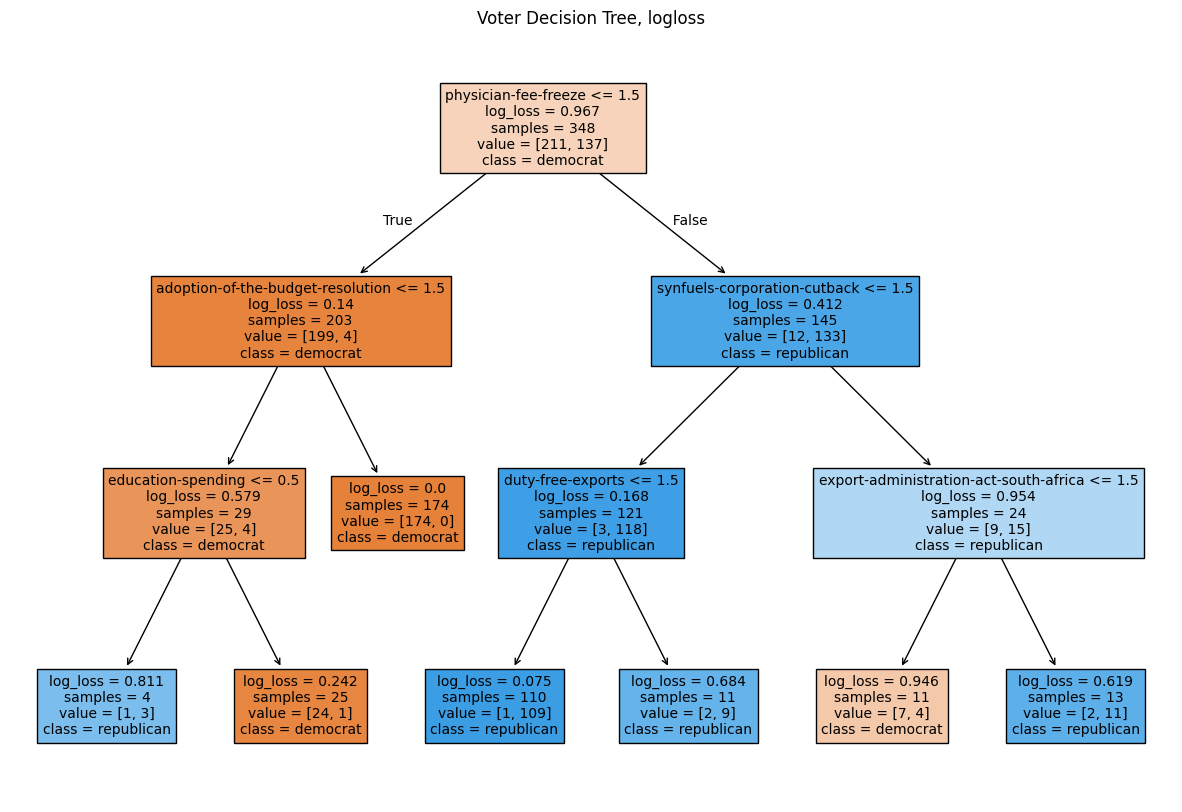

In [ ]:
tree_logloss =  DecisionTreeClassifier(criterion='log_loss', max_depth=3)
tree_logloss.fit(X_train, y_train)
plt.figure(figsize=(15, 10))
plot_tree(tree_logloss,
          feature_names=df_voter.columns,
          class_names=['democrat', 'republican'],
          filled=True,
          fontsize=10)
plt.title("Voter Decision Tree, logloss")
plt.show()

In [ ]:
tree_gini = DecisionTreeClassifier(criterion='gini')
tree_gini.fit(X_train, y_train)
print(f"training accuracy: {tree_gini.score(X_train, y_train)}")
print(f"test accuracy: {tree_gini.score(X_test, y_test)}")
print("\n")
print("Feature Importances:")
for i in range(len(feature_importances)):
  print(f"{df_voter.columns[i]}: {feature_importances[i]}")

training accuracy: 1.0
test accuracy: 0.9310344827586207


Feature Importances:
handicapped-infants: 0.0
water-project-cost-sharing: 0.0
adoption-of-the-budget-resolution: 0.0
physician-fee-freeze: 0.5707571064813255
el-salvador-aid: 0.0
religious-groups-in-schools: 0.42924289351867445


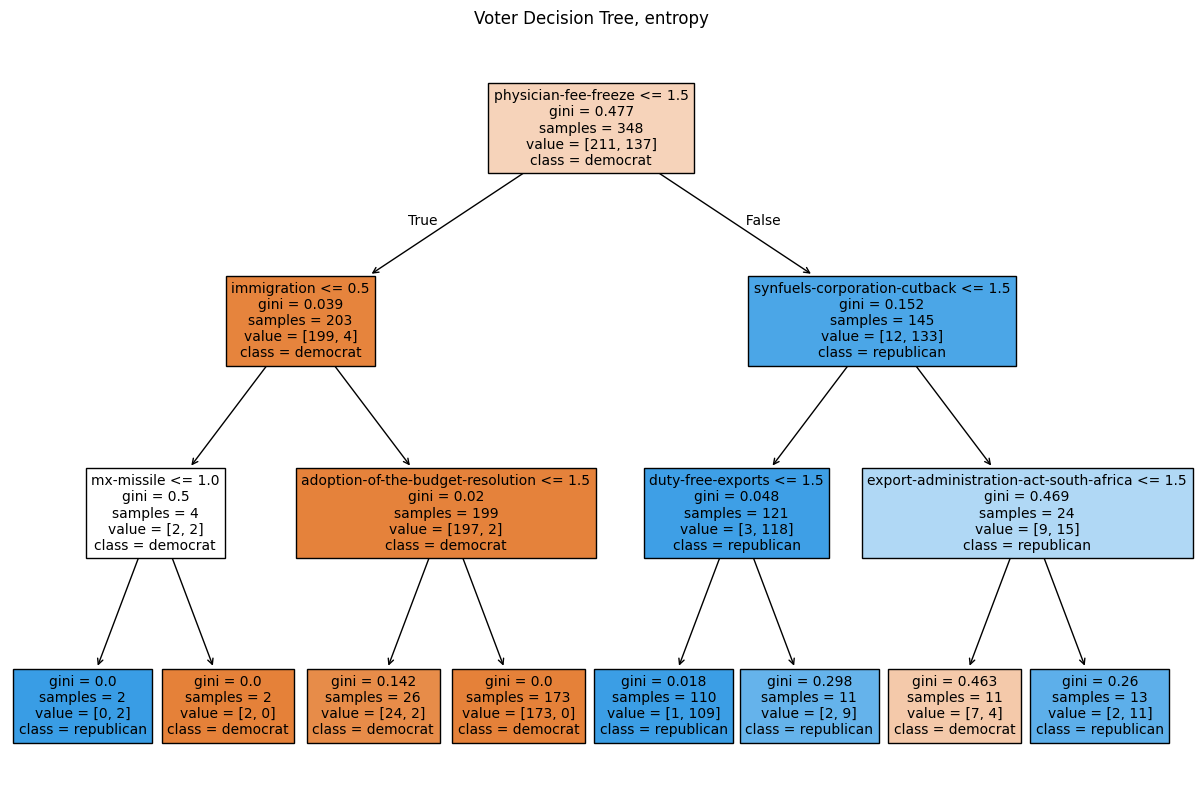

In [ ]:
tree_gini =  DecisionTreeClassifier(criterion='gini', max_depth=3)
tree_gini.fit(X_train, y_train)
plt.figure(figsize=(15, 10))
plot_tree(tree_gini,
          feature_names=df_voter.columns,
          class_names=['democrat', 'republican'],
          filled=True,
          fontsize=10)
plt.title("Voter Decision Tree, entropy")
plt.show()

#### Discussion
How does using different split criteria (entropy, log-loss, and gini) affect accuracy, tree structure, and feature importance?

The different tree split criteria curiously end up producing the exact same accuracies. I would assume that is because of the clear separability of this dataset when using decision trees. The structures of the trees with entropy and log_loss ended up exactly the same, but the gini tree did produce a slightly different structure. There were more branches to the tree, although the feature importances remain the same.

## 3 Overfit Avoidance with Decision Trees  

Above, you found typical training and test set scores for the Cars data set when the tree is induced as far as it can go (until classes are pure or there are no more data or attributes to split on).  This usually leads to great training set scores but can potentially overfit and get lower accuracy on the test set.  You will now experiment with methods which can help avoid overfit and which could lead to better test set accuracy (though training set accuracy may decrease).  

### 3.1 Smaller and Simpler Trees 
- tree_: [Read about](https://scikit-learn.org/stable/auto_examples/tree/plot_unveil_tree_structure.html#sphx-glr-auto-examples-tree-plot-unveil-tree-structure-py) the tree_ attribute with its sub attributes and methods allowing you to interact with your learned tree.  You don't have to do any specific task for this part.
- Use an 80/20 train/test split for all experiments in this part and induce (learn/fit) the full tree for Cars.
- For the fully induced tree print out
    - Training set accuracy
    - Test set accuracy
    - Total number of nodes (clf.tree_.node_count)
    - Maximum tree depth (clf.tree_.max_depth)
- Experiment with the following parameters which lead to smaller and/or simpler trees which can help with overfit.  Try a few different values of each parameter and compare their train and test set accuracies and number of nodes and depth with the fully induced tree.  If you are not sure how parameters are actually working, print some trees to see their effect.  Due to the simplicity of the Cars data set you may not see as great of accuracy improvements as you would for cases where overfit is more prominent.  
    - min_samples_leaf
    - min_samples_split
    - min_impurity_decrease
- Try these parameters also, but note that they could lead to underfit
    - max_depth
    - max_leaf_nodes
    - max_features

In [ ]:
# Explore different overfit parameters
data, metadata = arff.loadarff('cars.arff')
df_cars = pd.DataFrame(data)
for i in df_cars.columns:
  df_cars[i] = le.fit_transform(df_cars[i])
df_cars.head()
X_cars = df_cars.drop('class', axis=1)
y_cars = df_cars['class']
X_train, X_test, y_train, y_test = train_test_split(X_cars, y_cars, test_size=0.2, random_state=42)

In [ ]:
# tree with default parameters
tree1 = DecisionTreeClassifier()
tree1.fit(X_train, y_train)
print(f"training accuracy: {tree1.score(X_train, y_train)}")
print(f"test accuracy: {tree1.score(X_test, y_test)}")
print(f"total nodes: {tree1.tree_.node_count}")
print(f"max depth: {tree1.tree_.max_depth}")

training accuracy: 1.0
test accuracy: 0.9682080924855492
total nodes: 157
max depth: 13


In [ ]:
# tree with min_samples_leaf
tree2 = DecisionTreeClassifier(min_samples_leaf=4)
tree2.fit(X_train, y_train)
print(f"training accuracy: {tree2.score(X_train, y_train)}")
print(f"test accuracy: {tree2.score(X_test, y_test)}")
print(f"total nodes: {tree2.tree_.node_count}")
print(f"max depth: {tree2.tree_.max_depth}")

training accuracy: 0.9761215629522432
test accuracy: 0.9364161849710982
total nodes: 109
max depth: 11


In [ ]:
# tree with min_samples_split
tree3 = DecisionTreeClassifier(min_samples_split=8)
tree3.fit(X_train, y_train)
print(f"training accuracy: {tree3.score(X_train, y_train)}")
print(f"test accuracy: {tree3.score(X_test, y_test)}")
print(f"total nodes: {tree3.tree_.node_count}")
print(f"max depth: {tree3.tree_.max_depth}")

training accuracy: 0.9790159189580319
test accuracy: 0.9421965317919075
total nodes: 111
max depth: 11


In [ ]:
# tree with min_impurity_decrease
tree4 = DecisionTreeClassifier(min_impurity_decrease=0.001)
tree4.fit(X_train, y_train)
print(f"training accuracy: {tree4.score(X_train, y_train)}")
print(f"test accuracy: {tree4.score(X_test, y_test)}")
print(f"total nodes: {tree4.tree_.node_count}")
print(f"max depth: {tree4.tree_.max_depth}")

training accuracy: 0.9848046309696092
test accuracy: 0.9364161849710982
total nodes: 99
max depth: 11


#### Discussion
How did the methods used above help avoid overfit? How do you know? How did they affect accuracy (training and test) and tree structure? Which parameters helped the most with each dataset? How do you know?

With min_samples_leaf, increasing the parameter decreased the number of nodes and the depth of the tree, which would help avoid overfitting. The accuracy of both train and test went down as the parameter increased and as the tree shrunk.

The pattern was the same for the other two parameters - increasing the value decreased the amount of total nodes and depth of the tree, and accuracy in this particular dataset went down. I would expect, however, that a prevention of overfitting by using these parameters woudl actually help the test accuracy come much higher.

### 3.2 Tree Reduction
Another approach to avoiding overfit is using pruning to reduce fully induced trees.  Induce the tree fully for Cars (no simplifying parameters such as max_depth).  Prune by setting the [ccp_alpha](https://scikit-learn.org/stable/auto_examples/tree/plot_cost_complexity_pruning.html#sphx-glr-auto-examples-tree-plot-cost-complexity-pruning-py) parameter to a positive value. This parameter controls how aggressive the pruning is. Try some small values (e.g. ,001, ,005, etc.) and try to find and report the value which works the best.  Make a table with at least 5 ccp_alpha values and for each value include
- Training set accuracy (you chooses the size of the train/test split)
- Test set accuracy
- Total number of nodes (clf.tree_.node_count)
- Maximum tree depth (clf.tree_.max_depth)

In [ ]:
# Pruning
tree1.fit(X_train, y_train)
print(f"training accuracy: {tree1.score(X_train, y_train)}")
print(f"test accuracy: {tree1.score(X_test, y_test)}")

training accuracy: 1.0
test accuracy: 0.9682080924855492


In [ ]:
tree_regcar =  DecisionTreeClassifier(max_depth=3)
tree_regcar.fit(X_train, y_train)
path = tree_regcar.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas, impurities = path.ccp_alphas, path.impurities
ccp_alphas = [0.0001, 0.0005, 0.001, 0.005, 0.01]
for ccp_alpha in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=0, ccp_alpha=ccp_alpha)
    clf.fit(X_train, y_train)
    print(f"ccp_alpha: {ccp_alpha}")
    print(f"training accuracy: {clf.score(X_train, y_train)}")
    print(f"test accuracy: {clf.score(X_test, y_test)}")
    print(f"total nodes: {clf.tree_.node_count}")
    print(f"max depth: {clf.tree_.max_depth}")
    print("\n")

ccp_alpha: 0.0001
training accuracy: 1.0
test accuracy: 0.9682080924855492
total nodes: 157
max depth: 13


ccp_alpha: 0.0005
training accuracy: 0.9985528219971056
test accuracy: 0.9624277456647399
total nodes: 145
max depth: 13


ccp_alpha: 0.001
training accuracy: 0.9905933429811867
test accuracy: 0.9450867052023122
total nodes: 113
max depth: 12


ccp_alpha: 0.005
training accuracy: 0.947178002894356
test accuracy: 0.9190751445086706
total nodes: 49
max depth: 10


ccp_alpha: 0.01
training accuracy: 0.8762662807525325
test accuracy: 0.884393063583815
total nodes: 23
max depth: 6




#### Discussion
How did the pruning parameter ccp_alpha affect accuracy and tree structure? How does that compare to the methods above?

Pruning negatively affects the accuracy as we increase the ccp_alpha parameter in this particular dataset. It obviously cuts down the tree more as the ccp_alpha is increased. It seems to have a similar effect to the methods above.

## 4. Decision Tree Regression
### 4.1 Learn a real-world regression data set of your choice (not already used in this or previous labs)
- Report tree statistics (# of nodes, # of leaf nodes, max depth)
- Report MAE on the training and test set (you choose the size of the train/test split)
- Report the DT regressor score for the training and test set.  Note that for the DT regressor this score is the coefficient of determination. Google it if you are curious.

In [ ]:
#Learn regression data set
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error

In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17)

# data (as pandas dataframes)
X = breast_cancer_wisconsin_diagnostic.data.features
y = breast_cancer_wisconsin_diagnostic.data.targets

In [ ]:
print(X.head())

   radius1  texture1  perimeter1   area1  smoothness1  compactness1  \
0    17.99     10.38      122.80  1001.0      0.11840       0.27760   
1    20.57     17.77      132.90  1326.0      0.08474       0.07864   
2    19.69     21.25      130.00  1203.0      0.10960       0.15990   
3    11.42     20.38       77.58   386.1      0.14250       0.28390   
4    20.29     14.34      135.10  1297.0      0.10030       0.13280   

   concavity1  concave_points1  symmetry1  fractal_dimension1  ...  radius3  \
0      0.3001          0.14710     0.2419             0.07871  ...    25.38   
1      0.0869          0.07017     0.1812             0.05667  ...    24.99   
2      0.1974          0.12790     0.2069             0.05999  ...    23.57   
3      0.2414          0.10520     0.2597             0.09744  ...    14.91   
4      0.1980          0.10430     0.1809             0.05883  ...    22.54   

   texture3  perimeter3   area3  smoothness3  compactness3  concavity3  \
0     17.33      184.60 

In [ ]:
print(y.head())

  Diagnosis
0         M
1         M
2         M
3         M
4         M


In [ ]:
y = le.fit_transform(y)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [ ]:
# default parameters
Tree = DecisionTreeRegressor()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
Tree.fit(X_train, y_train)
print(f"training regressor score: {Tree.score(X_train, y_train)}")
print(f"test regressor score: {Tree.score(X_test, y_test)}")
print(f"train mean absolute error: {mean_absolute_error(y_train, Tree.predict(X_train))}")
print(f"test mean absolute error: {mean_absolute_error(y_test, Tree.predict(X_test))}")
print(f"total nodes: {Tree.tree_.node_count}")
print(f"max depth: {Tree.tree_.max_depth}")

training regressor score: 1.0
test regressor score: 0.7386177530298067
train mean absolute error: 0.0
test mean absolute error: 0.06140350877192982
total nodes: 31
max depth: 7


In [ ]:
# after parameter experimentation
Tree = DecisionTreeRegressor(min_samples_leaf=7, min_samples_split=4, min_impurity_decrease=0.0001)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
Tree.fit(X_train, y_train)
print(f"training regressor score: {Tree.score(X_train, y_train)}")
print(f"test regressor score: {Tree.score(X_test, y_test)}")
print(f"train mean absolute error: {mean_absolute_error(y_train, Tree.predict(X_train))}")
print(f"test mean absolute error: {mean_absolute_error(y_test, Tree.predict(X_test))}")
print(f"total nodes: {Tree.tree_.node_count}")
print(f"max depth: {Tree.tree_.max_depth}")

training regressor score: 0.9213439532495477
test regressor score: 0.8187775785710114
train mean absolute error: 0.03672755815612958
test mean absolute error: 0.05547960811118706
total nodes: 25
max depth: 6


In [ ]:
# pruning experimentation
ccp_alphas = [0.0001, 0.0005, 0.001, 0.005, 0.01]
for ccp_alpha in ccp_alphas:
    clf = DecisionTreeRegressor(min_samples_leaf=7, min_samples_split=4, min_impurity_decrease=0.0001, random_state=0, ccp_alpha=ccp_alpha)
    clf.fit(X_train, y_train)
    print(f"ccp_alpha: {ccp_alpha}")
    print(f"training score: {clf.score(X_train, y_train)}")
    print(f"test score: {clf.score(X_test, y_test)}")
    print(f"train mean absolute error: {mean_absolute_error(y_train, clf.predict(X_train))}")
    print(f"test mean absolute error: {mean_absolute_error(y_test, clf.predict(X_test))}")
    print(f"total nodes: {clf.tree_.node_count}")
    print(f"max depth: {clf.tree_.max_depth}")
    print("\n")

ccp_alpha: 0.0001
training score: 0.9213439532495477
test score: 0.8439251416905927
train mean absolute error: 0.03672755815612958
test mean absolute error: 0.04921394395078606
total nodes: 25
max depth: 6


ccp_alpha: 0.0005
training score: 0.9188061684536983
test score: 0.8466629812237729
train mean absolute error: 0.03791254828121187
test mean absolute error: 0.04969902762772033
total nodes: 19
max depth: 4


ccp_alpha: 0.001
training score: 0.9188061684536983
test score: 0.8466629812237729
train mean absolute error: 0.03791254828121187
test mean absolute error: 0.04969902762772033
total nodes: 19
max depth: 4


ccp_alpha: 0.005
training score: 0.8876688683667847
test score: 0.7964591414993224
train mean absolute error: 0.0524517610564891
test mean absolute error: 0.07497410172058439
total nodes: 11
max depth: 3


ccp_alpha: 0.01
training score: 0.860863574838083
test score: 0.7838365554819893
train mean absolute error: 0.06496819199397268
test mean absolute error: 0.080766093662160

#### Discussion
Discuss your choice of dataset and regression feature. Also discuss the items listed above in 4.1

I used the Breast Cancer Wisconsin dataset from the UC Irvine ML repository. It includes many factors that may predict the target (breast cancer). The diagnosis is either malignant or benign. The best regression model (the one with `ccp_alpha=0.001`) ended up with a test score of about 84%. It produced a tree with 19 total nodes and a max depth of 4. The mean absolute error was also relatively small at about 0.05. This shows that the model may help with suggesting the presence of breast cancer, but is not entirely reliable.